# MovieLens Recommendation System

## 1. Importing the Data and EDA

In [1]:
import pandas as pd

movies_df = pd.read_csv('./ml-latest-small/movies.csv')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
ratings_df = pd.read_csv('./ml-latest-small/ratings.csv')
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
movies_df.isna().sum(), ratings_df.isna().sum()

(movieId    0
 title      0
 genres     0
 dtype: int64,
 userId       0
 movieId      0
 rating       0
 timestamp    0
 dtype: int64)

In [10]:
movies_df.nunique()

movieId    9742
title      9737
genres      951
dtype: int64

In [4]:
movies_df.duplicated().sum(), ratings_df.duplicated().sum()

(0, 0)

## EDA

### 1. Average Rating per Genre

In [49]:
# Combining the two dataframes
combined_df = pd.merge(movies_df, ratings_df, on=['movieId'])

# Cleaning the Genre column
combined_df['genres'] = combined_df['genres'].str.split('|')
combined_df_exploded = combined_df.explode('genres')
combined_df_exploded.head()

# Dropping the Movies with no genre
combined_df_exploded = combined_df_exploded[combined_df_exploded['genres'] != '(no genres listed)']

# Grouping the Genres by Average Rating
avg_rating_per_genre = combined_df_exploded.groupby('genres')['rating'].mean().sort_values()
avg_rating_per_genre



genres
Horror         3.258195
Comedy         3.384721
Children       3.412956
Action         3.447984
Sci-Fi         3.455721
Fantasy        3.491001
Thriller       3.493706
Romance        3.506511
Adventure      3.508609
Musical        3.563678
Western        3.583938
IMAX           3.618335
Animation      3.629937
Mystery        3.632460
Drama          3.656184
Crime          3.658294
Documentary    3.797785
War            3.808294
Film-Noir      3.920115
Name: rating, dtype: float64

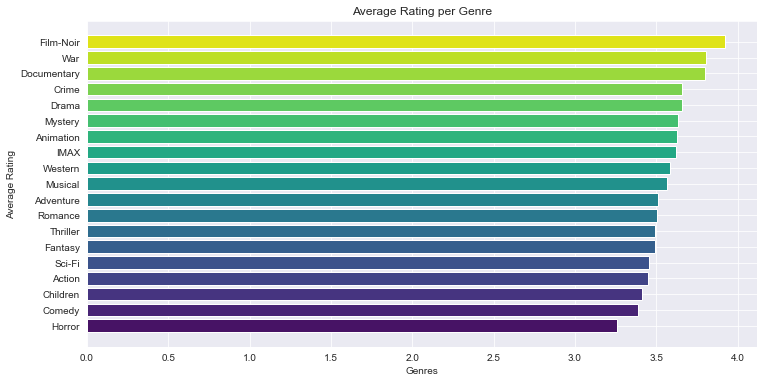

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

palette = sns.color_palette('viridis', len(avg_rating_per_genre))
plt.figure(figsize=(12,6))
plt.barh(avg_rating_per_genre.index, avg_rating_per_genre.values, color=palette)
plt.xlabel('Genres')
plt.ylabel('Average Rating')
plt.title('Average Rating per Genre')
plt.show()

### 2. Number of Ratings per User vs Average Rating

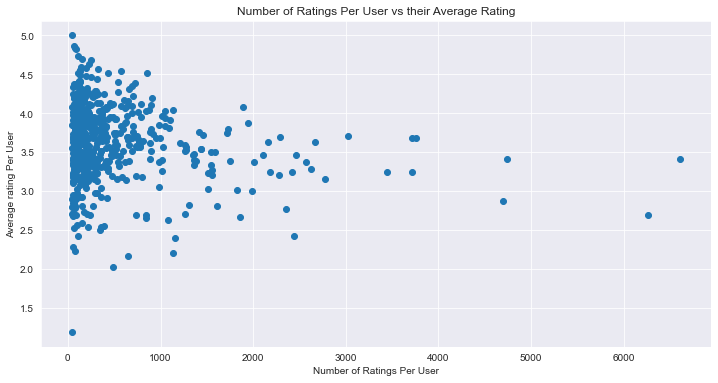

In [37]:
# Number of Ratings per User
num_of_ratings_per_user = combined_df_exploded.groupby('userId')['rating'].count()

# Average Rating per User
avg_rating_per_user = combined_df_exploded.groupby('userId')['rating'].mean()

# Scatterplot 
plt.figure(figsize=(12,6))
plt.scatter(num_of_ratings_per_user.values, avg_rating_per_user.values)
plt.xlabel('Number of Ratings Per User')
plt.ylabel('Average rating Per User')
plt.title('Number of Ratings Per User vs their Average Rating')
plt.show()

### 3. Distribution of Number of Ratings per Genre

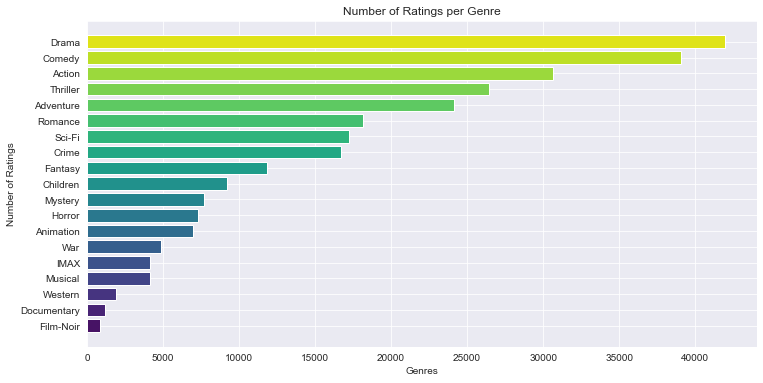

In [46]:
# Number of ratings per genre
num_of_ratings_per_genre = combined_df_exploded.groupby('genres')['rating'].count().sort_values()

# Number of Ratings per Genre Horizontal Bar Chart
plt.figure(figsize=(12,6))
plt.barh(num_of_ratings_per_genre.index, num_of_ratings_per_genre.values, color=palette)
plt.xlabel('Genres')
plt.ylabel('Number of Ratings')
plt.title('Number of Ratings per Genre')
plt.show()

### 4. Number of Ratings per Genre vs the Average Rating

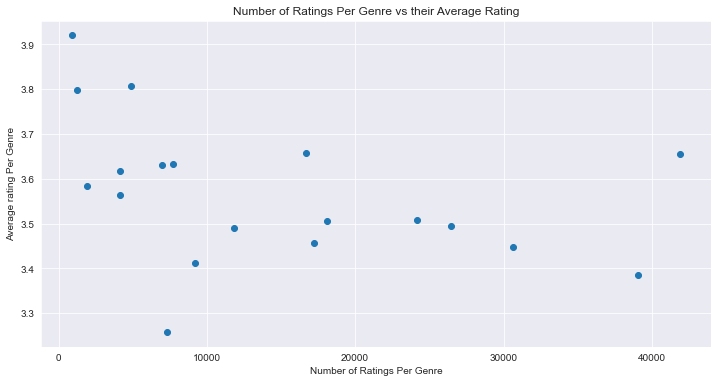

In [52]:
num_of_ratings_per_genre = num_of_ratings_per_genre.sort_index()
avg_rating_per_genre = avg_rating_per_genre.sort_index()

plt.figure(figsize=(12,6))
plt.scatter(num_of_ratings_per_genre.values, avg_rating_per_genre.values)
plt.xlabel('Number of Ratings Per Genre')
plt.ylabel('Average rating Per Genre')
plt.title('Number of Ratings Per Genre vs their Average Rating')
plt.show()

In [ ]:
new_ratings_df = ratings_df.drop('timestamp', axis=1)
new_ratings_df.head()

In [ ]:
user_id_range = (new_ratings_df['userId'].min(), new_ratings_df['userId'].max())
movie_id_range = (new_ratings_df['movieId'].min(), new_ratings_df['movieId'].max())
print('User ID range: ', user_id_range)
f"Movie ID range: {movie_id_range}"

In [ ]:
new_ratings_df['rating'].value_counts().sort_index()

## 2. Model Building

In [ ]:
from surprise import Reader, Dataset

data = Dataset.load_from_df(new_ratings_df, Reader(rating_scale=(0, 5)))

In [ ]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=2026)

In [ ]:
# Importing relevant libraries
from surprise.model_selection import GridSearchCV
from surprise.prediction_algorithms import SVD, KNNWithMeans, KNNBasic, KNNBaseline
from surprise import accuracy
import numpy as np

### a) SVD

In [ ]:
## Perform a gridsearch with SVD
# This cell may take several minutes to run
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 50],
    'lr_all': [0.005, 0.0005],
    'reg_all': [0.02, 0.04]
}
svd_model = GridSearchCV(
    algo_class=SVD,
    param_grid=param_grid,
    cv=3,
    refit=True,
    measures=['rmse']
)
svd_model.fit(data)

In [ ]:
# RMSE during cross-validation
print(svd_model.best_score['rmse'])
svd_model.best_params['rmse']

In [ ]:
# RMSE on test set
svd = SVD(
    n_factors=svd_model.best_params['rmse']['n_factors'],
    n_epochs=svd_model.best_params['rmse']['n_epochs'],
    lr_all=svd_model.best_params['rmse']['lr_all'],
    reg_all=svd_model.best_params['rmse']['reg_all']
)
svd.fit(trainset)
predictions = svd.test(testset)
svd_accuracy = accuracy.rmse(predictions)
svd_accuracy

### b) KNNBasic

In [ ]:
# Cross validating with KNNBasic
param_grid = {
    'k': [40, 50],
    'min_k': [1, 5],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}
knn_basic_model = GridSearchCV(
    algo_class=KNNBasic,
    param_grid=param_grid,
    refit=True,
    measures=['rmse'],
    cv=3
)
knn_basic_model.fit(data)

In [ ]:
# RMSE during cross-validation
print(knn_basic_model.best_score['rmse'])
knn_basic_model.best_params['rmse']

In [ ]:
# RMSE on test set
knn_basic = KNNBasic(
    k=knn_basic_model.best_params['rmse']['k'],
    min_k=knn_basic_model.best_params['rmse']['min_k'],
    sim_options=knn_basic_model.best_params['rmse']['sim_options']
)
knn_basic.fit(trainset)
predictions = knn_basic.test(testset)
knn_basic_accuracy = accuracy.rmse(predictions)
knn_basic_accuracy

### c) KNNBaseline

In [ ]:
# Cross validating with KNNBaseline
param_grid = {
    'k': [30, 40],
    'min_k': [5, 10],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}
knn_baseline_model = GridSearchCV(
    algo_class=KNNBaseline,
    param_grid=param_grid,
    refit=True,
    measures=['rmse'],
    cv=3
)
knn_baseline_model.fit(data)

In [ ]:
# RMSE during cross validation
print(knn_baseline_model.best_score['rmse'])
knn_baseline_model.best_params['rmse']

In [ ]:
# RMSE on test set
knn_baseline = KNNBaseline(
    k=knn_baseline_model.best_params['rmse']['k'],
    min_k=knn_baseline_model.best_params['rmse']['min_k'],
    sim_options=knn_baseline_model.best_params['rmse']['sim_options']
)
knn_baseline.fit(trainset)
predictions = knn_baseline.test(testset)
knn_baseline_accuracy = accuracy.rmse(predictions)
knn_baseline_accuracy

### d) KNNWithMeans

In [ ]:
# Cross validating with KNNWithMeans
param_grid = {
    'k': [30, 40],
    'min_k': [5, 10],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}
knn_with_means_model = GridSearchCV(
    algo_class=KNNWithMeans,
    param_grid=param_grid,
    refit=True,
    measures=['rmse'],
    cv=3
)
knn_with_means_model.fit(data)

In [ ]:
# RMSE during cross validation
print(knn_with_means_model.best_score['rmse'])
knn_with_means_model.best_params['rmse']

In [ ]:
# RMSE on test set
knn_with_means = KNNWithMeans(
    k=knn_with_means_model.best_params['rmse']['k'],
    min_k=knn_with_means_model.best_params['rmse']['min_k'],
    sim_options=knn_with_means_model.best_params['rmse']['sim_options']
)
knn_with_means.fit(trainset)
predictions = knn_with_means.test(testset)
knn_with_means_accuracy = accuracy.rmse(predictions)
knn_with_means_accuracy

### e) Final Evaluation

In [ ]:
# Store rmse scores for each model as the average of the cv and test rmses
scores = {
    svd: (svd_model.best_score['rmse'] + svd_accuracy) / 2,
    knn_basic: (knn_basic_model.best_score['rmse'] + knn_basic_accuracy) / 2,
    knn_baseline: (knn_baseline_model.best_score['rmse'] + knn_baseline_accuracy) / 2,
    knn_with_means: (knn_with_means_model.best_score['rmse'] + knn_with_means_accuracy) / 2
}

In [ ]:
# Get the best model dynamically as the model with the least avg rmse
best_model = min(scores, key=lambda model: scores[model])

## 3. Making Predictions

In [ ]:
best_model.predict(1, 3)

## 4. Recommendation Functions

### a) Existing Users

In [ ]:
def get_existing_user_recommendations(user_id, ratings_dataframe, movies_dataframe, best_model, k=5):
    # Retrain the model as this function will be used later
    data = Dataset.load_from_df(ratings_dataframe, Reader(rating_scale=(0, 5)))
    trainset = data.build_full_trainset()
    best_model.fit(trainset)
    
    # Get predictions for movies the user has not seen using the already fitted best model
    all_movie_ids = ratings_dataframe['movieId'].unique()
    user_movie_ids = ratings_dataframe['movieId'].loc[ratings_dataframe['userId'] == user_id].unique()
    predictions = [(movie_id, best_model.predict(user_id, movie_id).est) for movie_id in all_movie_ids if movie_id not in user_movie_ids]
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Return the top k movie titles
    top_k = predictions[:k]
    top_k_titles = [
        movies_dataframe.loc[movies_dataframe['movieId'] == movie_id, 'title'].values[0]
        for movie_id, _ in top_k
    ]
    return top_k_titles

In [ ]:
get_existing_user_recommendations(1, new_ratings_df, movies_df, best_model=best_model)

### b) New users

In [ ]:
# Helper function to get a valid user id
def get_valid_user_id(ratings_dataframe):
    return ratings_dataframe['userId'].max() + 1

In [ ]:
# Helper function to get k ratings from the user
def get_sample_ratings(user_id, movies_dataframe, samples_num=5):
    rated = 0
    sampled_indices = []
    ratings = []

    while rated < samples_num:
        remaining = movies_dataframe.drop(index=sampled_indices)
        sample = remaining.sample(1)
        sampled_indices.append(sample.index[0])
        print(f"Movie #{rated + 1}")
        rating = input(f"Rate this movie '{sample['title'].values[0]}' (Click Enter if you have not seen it): ")

        if rating == '':
            continue
        
        ratings.append({
            'userId': user_id,
            'movieId': sample['movieId'].values[0],
            'rating': float(rating)
        })
        rated += 1
    
    return ratings

In [ ]:
def get_new_user_recommendations(ratings_dataframe, movies_dataframe, the_best_model, num_samples=5, k=5):
    # First, give the new user a valid id
    new_user_id = get_valid_user_id(ratings_dataframe=ratings_dataframe)

    # Get sample ratings from the user to solve cold-start problem
    new_user_ratings = get_sample_ratings(new_user_id, movies_dataframe, num_samples)

    # Add these new ratings to the original dataframe
    new_user_ratings_df = pd.DataFrame(new_user_ratings)
    new_ratings_dataframe = pd.concat([ratings_dataframe, new_user_ratings_df], ignore_index=True)

    # Use this new ratings df to get recommendations
    return get_existing_user_recommendations(new_user_id, new_ratings_dataframe, movies_dataframe, the_best_model)


In [ ]:
get_new_user_recommendations(new_ratings_df, movies_df, best_model)